In [21]:
# load all libraries
import seaborn as sns
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier,plot_tree
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

In [22]:
# Unzip the main archive, which contains other zip files
!unzip -o /content/bank+marketing.zip -d /content/

# Unzip the 'bank-additional' dataset, which contains the CSV file
# Assuming bank-additional.zip exists after the first unzip
!unzip -o /content/bank-additional.zip -d /content/

Archive:  /content/bank+marketing.zip
 extracting: /content/bank.zip       
 extracting: /content/bank-additional.zip  
Archive:  /content/bank-additional.zip
  inflating: /content/bank-additional/.DS_Store  
  inflating: /content/__MACOSX/bank-additional/._.DS_Store  
  inflating: /content/bank-additional/.Rhistory  
  inflating: /content/bank-additional/bank-additional-full.csv  
  inflating: /content/bank-additional/bank-additional-names.txt  
  inflating: /content/bank-additional/bank-additional.csv  
  inflating: /content/__MACOSX/._bank-additional  


In [23]:
#load the data sets
# Load the dataset
df = pd.read_csv('/content/bank-additional/bank-additional-full.csv', sep=';')

# Display the first 3 rows to verify
display(df.head(5))

,age,job,marital,education,default,housing,loan,contact,month,day_of_week,...,campaign,pdays,previous,poutcome,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,y
0,56,housemaid,married,basic.4y,no,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
1,57,services,married,high.school,unknown,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
2,37,services,married,high.school,no,yes,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
3,40,admin.,married,basic.6y,no,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
4,56,services,married,high.school,no,no,yes,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no


In [24]:
# data Preprocessing(Encoding)
# 1. Separate features (X) and target (y)
X = df.drop('y', axis=1)
y = df['y']

# 2. Convert text columns into numbers using One-Hot Encoding
X_encoded = pd.get_dummies(X, drop_first=True)

# 3. Convert target variable 'yes'/'no' into 1/0
y_encoded = y.map({'yes': 1, 'no': 0})

print(f"Original features shape: {X.shape}")
print(f"Encoded features shape: {X_encoded.shape}")

Original features shape: (41188, 20)
Encoded features shape: (41188, 53)


In [25]:
# train-test split
X_train, X_test, y_train, y_test = train_test_split(X_encoded, y_encoded, test_size=0.2, random_state=42)

print(f"Training data size: {X_train.shape[0]} rows")
print(f"Testing data size: {X_test.shape[0]} rows")

Training data size: 32950 rows
Testing data size: 8238 rows


In [26]:
# Step 5: Build and Train the Decision Tree Mode
# Initialize the model
# We limit depth to 5 to keep the model general and avoid overfitting
clf = DecisionTreeClassifier(criterion='gini', max_depth=5, random_state=42)

# Train the model using the training data
clf.fit(X_train, y_train)

print("Model successfully trained!")

Model successfully trained!


In [27]:
# Step 6: Prediction and Evaluation (Tying it back to your code!)
# Predict on the test set
y_pred = clf.predict(X_test)

# Calculate accuracy
accuracy = accuracy_score(y_test, y_pred)
print(f"Model Accuracy: {accuracy * 100:.2f}%\n")

# Display the classification report
print("Classification Report:")
print(classification_report(y_test, y_pred))

Model Accuracy: 91.50%

Classification Report:
              precision    recall  f1-score   support

           0       0.94      0.96      0.95      7303
           1       0.65      0.54      0.59       935

    accuracy                           0.92      8238
   macro avg       0.80      0.75      0.77      8238
weighted avg       0.91      0.92      0.91      8238



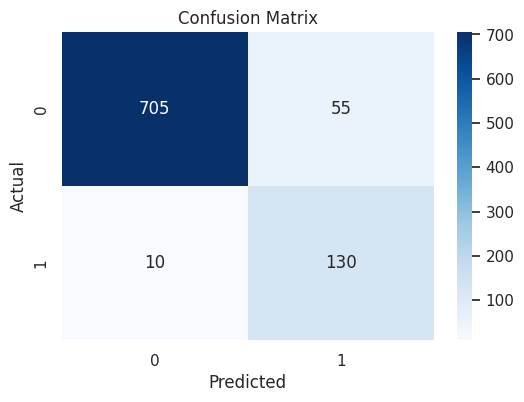

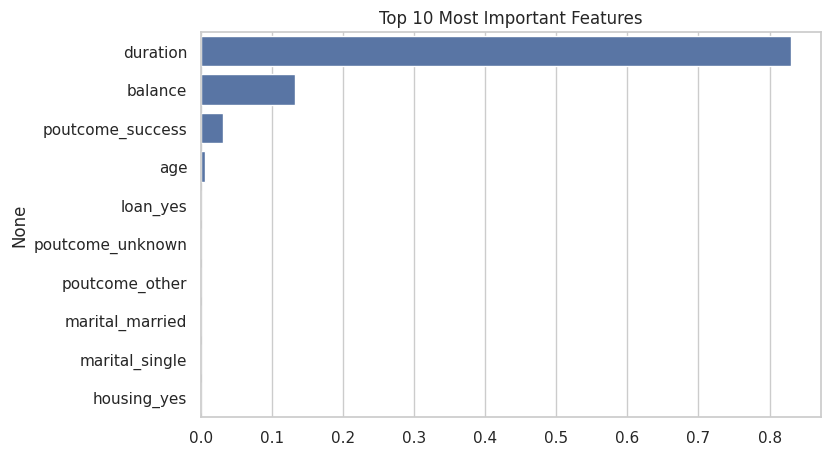

In [31]:

# 1. Plot the Confusion Matrix
plt.figure(figsize=(6, 4))
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title('Confusion Matrix')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.show()

# 2. Plot Feature Importances
importances = clf.feature_importances_
indices = np.argsort(importances)[::-1][:10] # Get top 10

plt.figure(figsize=(8, 5))
sns.barplot(x=importances[indices], y=X_encoded.columns[indices])
plt.title('Top 10 Most Important Features')
plt.show()